# PART 6

Haikal Ali_1103223071_TK46GAB

# Chapter 6 - Matrices, Part 2


In [1]:
import numpy as np
import scipy.linalg
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
np.random.seed(42)

## 1. Matrix Norms

Norm matriks menghasilkan satu angka yang merepresentasikan karakteristik matriks. Materi ini membedakan norm menjadi dua keluarga besar: **element-wise norm** dan **induced norm**.

Fokus bab ini adalah **element-wise norm**, terutama **Frobenius norm**. Frobenius norm dihitung dengan akar dari jumlah kuadrat semua elemen matriks:

$$
\|A\|_F = \sqrt{\sum_{i=1}^{M}\sum_{j=1}^{N} a_{ij}^2}
$$

Frobenius norm juga dapat digunakan untuk mengukur jarak antar matriks:

$$
\|A-B\|_F
$$

In [2]:
A = np.random.randn(4, 5)

fro_manual = np.sqrt(np.sum(A**2))
fro_numpy = np.linalg.norm(A, 'fro')

print('Frobenius manual :', fro_manual)
print('Frobenius NumPy  :', fro_numpy)
print('Selisih          :', abs(fro_manual - fro_numpy))

Frobenius manual : 4.25420977062536
Frobenius NumPy  : 4.25420977062536
Selisih          : 0.0


## 2. Matrix Trace dan Frobenius Norm

Trace matriks adalah jumlah elemen diagonal matriks dan hanya berlaku untuk matriks persegi.

Materi menunjukkan hubungan penting:

$$
\|A\|_F = \sqrt{tr(A^T A)}
$$

Artinya, Frobenius norm bisa dihitung dari trace hasil perkalian matriks dengan transposenya.

In [3]:
A = np.random.randn(4, 5)

fro_formula = np.sqrt(np.sum(A**2))
fro_trace_AtA = np.sqrt(np.trace(A.T @ A))
fro_trace_AAt = np.sqrt(np.trace(A @ A.T))

print('Formula elemen-wise  :', fro_formula)
print('Trace A.T @ A        :', fro_trace_AtA)
print('Trace A @ A.T        :', fro_trace_AAt)

Formula elemen-wise  : 4.38403183707769
Trace A.T @ A        : 4.38403183707769
Trace A @ A.T        : 4.38403183707769


## 3. Matrix Spaces

Terdapat beberapa ruang yang berkaitan dengan matriks:

- **Column space**: semua kombinasi linear dari kolom-kolom matriks.
- **Row space**: semua kombinasi linear dari baris-baris matriks.
- **Null space**: semua vektor yang jika dikalikan dengan matriks menghasilkan vektor nol.

Column space dapat diringkas dengan bentuk:

$$
Ax=b
$$

Null space diringkas dengan bentuk:

$$
Ay=0
$$

Solusi trivial $y=0$ tidak dianggap sebagai null space yang menarik.

In [4]:
A = np.array([[1, -1], [-2, 2]])
B = np.array([[1, -1], [-2, 3]])

print('Null space A:')
print(scipy.linalg.null_space(A))

print()
print('Null space B:')
print(scipy.linalg.null_space(B))

Null space A:
[[0.7071]
 [0.7071]]

Null space B:
[]


Pada contoh di atas, matriks `A` memiliki null space nontrivial karena kolom-kolomnya bergantung linear. Matriks `B` tidak memiliki null space nontrivial karena kolom-kolomnya independen linear.

## 4. Rank

Rank adalah bilangan bulat non-negatif yang berkaitan dengan banyaknya informasi independen dalam matriks.

Beberapa poin penting dari materi:

- Rank maksimum matriks berukuran $M 	imes N$ adalah $\min(M,N)$.
- Matriks full-rank memiliki rank maksimum.
- Matriks reduced-rank / singular memiliki rank lebih kecil dari rank maksimum.
- Rank bisa dipahami sebagai jumlah kolom atau baris terbesar yang membentuk himpunan independen linear.
- Rank juga dapat dihitung sebagai jumlah singular value yang tidak nol.

In [5]:
A = np.array([[1, 3], [2, 6], [4, 12]])
B = np.array([[1, 3.1], [2, 6], [4, 12]])

print('Rank A:', np.linalg.matrix_rank(A))
print('Rank B:', np.linalg.matrix_rank(B))

Rank A: 1
Rank B: 2


## 5. Rank pada Matriks Khusus

Ringkasan dari materi:

- Vektor nonzero memiliki rank 1.
- Matriks nol memiliki rank 0.
- Matriks identitas $I_N$ memiliki rank $N$.
- Rank matriks diagonal sama dengan jumlah elemen diagonal yang tidak nol.
- Matriks triangular full-rank jika semua elemen diagonalnya tidak nol.
- Random matrix dari bilangan floating point umumnya memiliki rank maksimum.
- Rank-1 matrix dapat dibuat dari outer product dua vektor nonzero.

In [6]:
z = np.zeros((4, 4))
I = np.eye(4)
D = np.diag([1, 0, 3, 0])
u = np.array([[4], [2], [3]])
v = np.array([[3, 1, 1, 3, 1]])
R1 = u @ v

print('Rank zeros matrix  :', np.linalg.matrix_rank(z))
print('Rank identity      :', np.linalg.matrix_rank(I))
print('Rank diagonal      :', np.linalg.matrix_rank(D))
print('Rank outer product :', np.linalg.matrix_rank(R1))
print(R1)

Rank zeros matrix  : 0
Rank identity      : 4
Rank diagonal      : 2
Rank outer product : 1
[[12  4  4 12  4]
 [ 6  2  2  6  2]
 [ 9  3  3  9  3]]


## 6. Rank dari Penjumlahan dan Perkalian Matriks

Materi memberikan dua aturan batas atas:

$$
rank(A+B) \le rank(A) + rank(B)
$$

$$
rank(AB) \le \min(rank(A), rank(B))
$$

Rank hasil penjumlahan atau perkalian tidak bisa langsung diketahui hanya dari rank masing-masing matriks, tetapi rank masing-masing matriks memberi batas atas.

## 7. Rank dari Shifted Matrix

Shifting matriks berarti menambahkan konstanta pada diagonal:

$$
A + \lambda I
$$

Menurut materi, shifting pada matriks persegi dapat menaikkan rank menjadi full-rank. Ini penting untuk stabilitas numerik dan regularisasi.

In [7]:
A = np.array([[1, 3, 2],
              [5, 7, 2],
              [2, 2, 0]])

shifted_A = A + 0.01*np.eye(3)

print('Rank A         :', np.linalg.matrix_rank(A))
print('Rank shifted A :', np.linalg.matrix_rank(shifted_A))
print()
print('A shifted:')
print(shifted_A)

Rank A         : 2
Rank shifted A : 3

A shifted:
[[1.01 3.   2.  ]
 [5.   7.01 2.  ]
 [2.   2.   0.01]]


## 8. Rank Applications

### Apakah v berada di column space A?

Algoritma dari materi:

1. Augment matriks $A$ dengan vektor $v$.
2. Hitung rank matriks asli dan rank matriks augmented.
3. Jika rank sama, maka $v \in C(A)$.
4. Jika rank augmented lebih besar, maka $v
otin C(A)$.

### Linear independence dari vector set

Algoritmanya:

1. Susun vektor-vektor menjadi matriks.
2. Hitung rank matriks.
3. Bandingkan rank dengan jumlah kolom.
4. Jika rank sama dengan jumlah kolom, maka vektor-vektor independen linear.

In [8]:
A = np.random.randn(4, 3)
v = np.random.randn(4, 1)
A_aug = np.hstack((A, v))

rank_A = np.linalg.matrix_rank(A)
rank_A_aug = np.linalg.matrix_rank(A_aug)

print('Rank A         :', rank_A)
print('Rank augmented :', rank_A_aug)
print('v di column space A?', rank_A == rank_A_aug)

Rank A         : 3
Rank augmented : 4
v di column space A? False


## 9. Determinant

Determinant adalah bilangan yang hanya dimiliki matriks persegi.

Dua poin utama dari materi:

- Determinant hanya berlaku untuk matriks persegi.
- Determinant bernilai nol untuk matriks reduced-rank / singular.

Untuk matriks $2 * 2$:
$$
\text{det}(A) = (a \times d) - (b \times c)
$$

In [9]:
A = np.array([[2, 7],
              [4, 16]])

manual_det = A[0, 0]*A[1, 1] - A[0, 1]*A[1, 0]
numpy_det = np.linalg.det(A)

print('Determinant manual:', manual_det)
print('Determinant NumPy :', numpy_det)

Determinant manual: 4
Determinant NumPy : 4.0


## 10. Characteristic Polynomial

Characteristic polynomial menggabungkan shifting matrix dengan determinant:

$$
\det(A - \lambda I) = \Delta
$$

Materi menunjukkan bahwa solusi dari characteristic polynomial saat determinant dibuat nol akan menjadi eigenvalues matriks. Detail eigenvalues dibahas pada bab berikutnya.

# Code Exercises

## Exercise 6-1

Buat eksperimen untuk menunjukkan hubungan antara skala matriks dan Frobenius norm. Setiap scalar dari 0 sampai 50 digunakan untuk mengalikan matriks random $10 	imes 10$, lalu norm dihitung. Eksperimen diulang 10 kali.

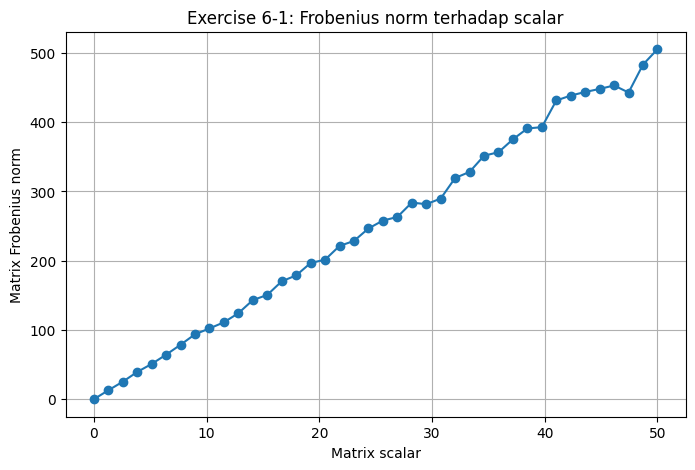

In [10]:
n_iters = 10
scalars = np.linspace(0, 50, 40)
norms = np.zeros((len(scalars), n_iters))

for si, scalar in enumerate(scalars):
  for it in range(n_iters):
    A = np.random.randn(10, 10)
    norms[si, it] = np.linalg.norm(scalar*A, 'fro')

mean_norms = np.mean(norms, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(scalars, mean_norms, 'o-')
plt.xlabel('Matrix scalar')
plt.ylabel('Matrix Frobenius norm')
plt.title('Exercise 6-1: Frobenius norm terhadap scalar')
plt.grid(True)
plt.show()

Hasilnya menunjukkan bahwa Frobenius norm meningkat seiring scalar membesar. Norm selalu non-negatif dan bernilai nol ketika scalar bernilai nol.

## Exercise 6-2

Buat fungsi Frobenius distance, lalu cari scalar yang membuat jarak Frobenius antara dua matriks turun hingga di bawah 1.

In [11]:
def frobenius_distance(A, B):
  return np.linalg.norm(A - B, 'fro')

N = 7
A = np.random.randn(N, N)
B = np.random.randn(N, N)

s = 1
iters = 0
dist = frobenius_distance(s*A, s*B)

while dist > 1:
  s *= 0.9
  iters += 1
  dist = frobenius_distance(s*A, s*B)

print('Jumlah iterasi :', iters)
print('Scalar akhir   :', s)
print('Jarak akhir    :', dist)

Jumlah iterasi : 21
Scalar akhir   : 0.10941898913151243
Jarak akhir    : 0.9966631118361738


Karena kedua matriks dikalikan scalar yang makin kecil, jarak Frobenius antar keduanya ikut mengecil.

## Exercise 6-3

Tunjukkan bahwa metode trace dan formula Euclidean menghasilkan Frobenius norm yang sama. Uji juga apakah $A^TA$ dan $AA^T$ menghasilkan nilai yang sama.

In [12]:
A = np.random.randn(5, 8)

fro_euclid = np.sqrt(np.sum(A**2))
fro_trace_AtA = np.sqrt(np.trace(A.T @ A))
fro_trace_AAt = np.sqrt(np.trace(A @ A.T))

print('Euclidean formula :', fro_euclid)
print('Trace A.T @ A     :', fro_trace_AtA)
print('Trace A @ A.T     :', fro_trace_AAt)

print()
print('Sama dengan A.T @ A?', np.isclose(fro_euclid, fro_trace_AtA))
print('Sama dengan A @ A.T?', np.isclose(fro_euclid, fro_trace_AAt))

Euclidean formula : 7.2398481869561
Trace A.T @ A     : 7.2398481869561
Trace A @ A.T     : 7.239848186956101

Sama dengan A.T @ A? True
Sama dengan A @ A.T? True


Metode trace bekerja untuk $A^TA$ dan $AA^T$ karena keduanya menjumlahkan kuadrat elemen-elemen matriks asli pada diagonal hasil perkalian.

## Exercise 6-4

Eksplorasi efek shifting terhadap norm matriks, jarak Frobenius, dan korelasi elemen matriks.

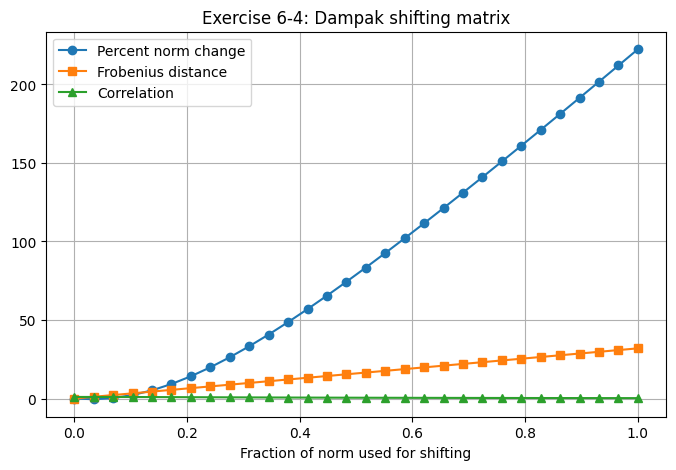

In [13]:
A = np.random.randn(10, 10)
orig_norm = np.linalg.norm(A, 'fro')
fractions = np.linspace(0, 1, 30)

pct_norm_change = np.zeros(len(fractions))
fro_distances = np.zeros(len(fractions))
correlations = np.zeros(len(fractions))

for i, frac in enumerate(fractions):
  shifted = A + frac*orig_norm*np.eye(A.shape[0])
  shifted_norm = np.linalg.norm(shifted, 'fro')

  pct_norm_change[i] = 100 * (shifted_norm - orig_norm) / orig_norm
  fro_distances[i] = np.linalg.norm(shifted - A, 'fro')
  correlations[i] = np.corrcoef(A.flatten(), shifted.flatten())[0, 1]

plt.figure(figsize=(8, 5))
plt.plot(fractions, pct_norm_change, 'o-', label='Percent norm change')
plt.plot(fractions, fro_distances, 's-', label='Frobenius distance')
plt.plot(fractions, correlations, '^-', label='Correlation')
plt.xlabel('Fraction of norm used for shifting')
plt.title('Exercise 6-4: Dampak shifting matrix')
plt.legend()
plt.grid(True)
plt.show()

Semakin besar shifting, perubahan norm dan jarak Frobenius meningkat. Korelasi elemen matriks asli dan matriks shifted cenderung menurun karena elemen diagonal berubah semakin besar.

## Exercise 6-5

Buat matriks random dengan rank arbitrer. Untuk membuat matriks $M 	imes N$ dengan rank $r$, kalikan matriks random berukuran $M 	imes r$ dengan matriks random berukuran $r 	imes N$.

In [14]:
M = 8
N = 10
r = 4

A = np.random.randn(M, r) @ np.random.randn(r, N)

print('Shape A:', A.shape)
print('Rank A :', np.linalg.matrix_rank(A))

r_too_large = 12
B = np.random.randn(M, r_too_large) @ np.random.randn(r_too_large, N)

print()
print('Shape B:', B.shape)
print('r yang diminta:', r_too_large)
print('Rank B aktual :', np.linalg.matrix_rank(B))
print('Rank maksimum :', min(M, N))

Shape A: (8, 10)
Rank A : 4

Shape B: (8, 10)
r yang diminta: 12
Rank B aktual : 8
Rank maksimum : 8


Jika $r > \min(M,N)$, rank aktual tidak bisa melebihi $\min(M,N)$ karena itu adalah rank maksimum matriks berukuran $M 	imes N$.

## Exercise 6-6

Demonstrasikan aturan rank untuk penjumlahan dan perkalian matriks.

In [15]:
# Penjumlahan rank-1 menghasilkan rank-0
A0 = np.outer([1, 2], [3, 4])
B0 = -A0

# Penjumlahan rank-1 menghasilkan rank-1
A1 = np.outer([1, 2], [3, 4])
B1 = np.outer([1, 2], [6, 8])

# Penjumlahan rank-1 menghasilkan rank-2
A2 = np.outer([1, 0], [1, 0])
B2 = np.outer([0, 1], [0, 1])

pairs_add = [(A0, B0), (A1, B1), (A2, B2)]

for i, (A, B) in enumerate(pairs_add):
  print(f'Penjumlahan pasangan {i}:')
  print('rank(A)   =', np.linalg.matrix_rank(A))
  print('rank(B)   =', np.linalg.matrix_rank(B))
  print('rank(A+B) =', np.linalg.matrix_rank(A+B))
  print()

# Perkalian dua rank-1 matrix tidak bisa menghasilkan rank-2
# karena rank(AB) <= min(rank(A), rank(B)) = 1.
A_prod0 = np.outer([1, 0], [1, 0])
B_prod0 = np.outer([0, 1], [1, 0])

A_prod1 = np.outer([1, 2], [3, 4])
B_prod1 = np.outer([4, 5], [6, 7])

for name, A, B in [('Produk rank-0', A_prod0, B_prod0), ('Produk rank-1', A_prod1, B_prod1)]:
  print(name)
  print('rank(A)   =', np.linalg.matrix_rank(A))
  print('rank(B)   =', np.linalg.matrix_rank(B))
  print('rank(A@B) =', np.linalg.matrix_rank(A@B))
  print()

Penjumlahan pasangan 0:
rank(A)   = 1
rank(B)   = 1
rank(A+B) = 0

Penjumlahan pasangan 1:
rank(A)   = 1
rank(B)   = 1
rank(A+B) = 1

Penjumlahan pasangan 2:
rank(A)   = 1
rank(B)   = 1
rank(A+B) = 2

Produk rank-0
rank(A)   = 1
rank(B)   = 1
rank(A@B) = 0

Produk rank-1
rank(A)   = 1
rank(B)   = 1
rank(A@B) = 1



Untuk penjumlahan, dua matriks rank-1 bisa menghasilkan rank 0, 1, atau 2. Untuk perkalian dua matriks rank-1, hasil tidak bisa rank 2 karena rank produk dibatasi oleh rank terkecil dari matriks pengalinya.

## Exercise 6-7

Buat fungsi untuk menghasilkan matriks random $M 	imes M$ dengan rank $r$. Lalu buat pasangan matriks $20 	imes 20$ dengan rank 2 sampai 15, kemudian simpan rank hasil penjumlahan dan perkalian.

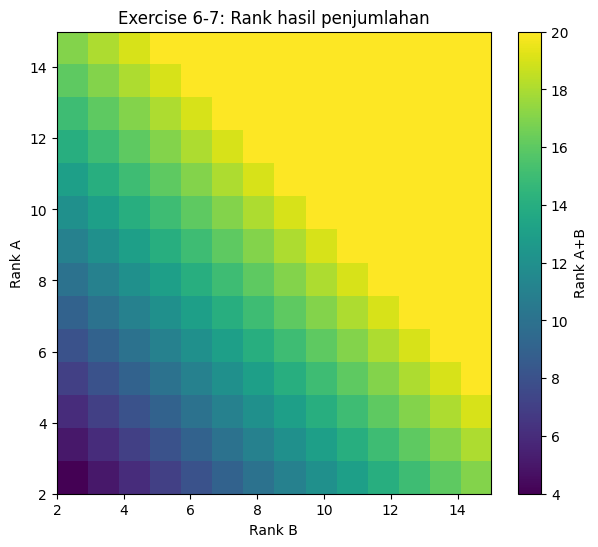

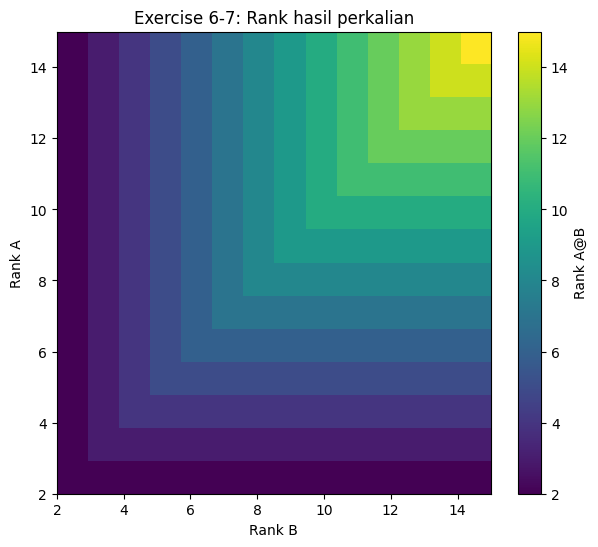

In [16]:
def random_rank_matrix(M, r):
  return np.random.randn(M, r) @ np.random.randn(r, M)

M = 20
ranks = np.arange(2, 16)
rank_add = np.zeros((len(ranks), len(ranks)))
rank_mul = np.zeros((len(ranks), len(ranks)))

for i, rA in enumerate(ranks):
  for j, rB in enumerate(ranks):
    A = random_rank_matrix(M, rA)
    B = random_rank_matrix(M, rB)
    rank_add[i, j] = np.linalg.matrix_rank(A + B)
    rank_mul[i, j] = np.linalg.matrix_rank(A @ B)

plt.figure(figsize=(7, 6))
plt.imshow(rank_add, origin='lower', extent=[ranks[0], ranks[-1], ranks[0], ranks[-1]], aspect='auto')
plt.colorbar(label='Rank A+B')
plt.xlabel('Rank B')
plt.ylabel('Rank A')
plt.title('Exercise 6-7: Rank hasil penjumlahan')
plt.show()

plt.figure(figsize=(7, 6))
plt.imshow(rank_mul, origin='lower', extent=[ranks[0], ranks[-1], ranks[0], ranks[-1]], aspect='auto')
plt.colorbar(label='Rank A@B')
plt.xlabel('Rank B')
plt.ylabel('Rank A')
plt.title('Exercise 6-7: Rank hasil perkalian')
plt.show()

Hasil penjumlahan dapat naik hingga batas $rank(A)+rank(B)$, sedangkan hasil perkalian tidak melebihi rank terkecil dari matriks yang dikalikan.

## Exercise 6-8

Tunjukkan bahwa $A$, $A^T$, $A^TA$, dan $AA^T$ memiliki rank yang sama untuk berbagai ukuran dan rank matriks.

In [17]:
tests = [
  (8, 5, 3),   # tall
  (5, 8, 3),   # wide
  (6, 6, 4),   # square
  (10, 7, 5),
]

for M, N, r in tests:
  A = np.random.randn(M, r) @ np.random.randn(r, N)
  ranks_result = {
    'A': np.linalg.matrix_rank(A),
    'A.T': np.linalg.matrix_rank(A.T),
    'A.T @ A': np.linalg.matrix_rank(A.T @ A),
    'A @ A.T': np.linalg.matrix_rank(A @ A.T),
  }
  print(f'Shape A = {M} x {N}, target rank = {r}')
  print(ranks_result)
  print()

Shape A = 8 x 5, target rank = 3
{'A': np.int64(3), 'A.T': np.int64(3), 'A.T @ A': np.int64(3), 'A @ A.T': np.int64(3)}

Shape A = 5 x 8, target rank = 3
{'A': np.int64(3), 'A.T': np.int64(3), 'A.T @ A': np.int64(3), 'A @ A.T': np.int64(3)}

Shape A = 6 x 6, target rank = 4
{'A': np.int64(4), 'A.T': np.int64(4), 'A.T @ A': np.int64(4), 'A @ A.T': np.int64(4)}

Shape A = 10 x 7, target rank = 5
{'A': np.int64(5), 'A.T': np.int64(5), 'A.T @ A': np.int64(5), 'A @ A.T': np.int64(5)}



Rank keempat bentuk tersebut sama karena transpose tidak mengubah jumlah informasi independen, dan perkalian dengan transpose mempertahankan rank matriks asal.

## Exercise 6-9

Jawab pertanyaan apakah $v \in C(A)$ dengan membandingkan rank matriks asli dan rank matriks augmented.

In [18]:
def is_in_column_space(A, v):
  v = np.asarray(v)
  if v.ndim == 1:
    v = v.reshape(-1, 1)

  if A.shape[0] != v.shape[0]:
    raise ValueError('Jumlah baris v harus sama dengan jumlah baris A untuk augmentasi.')

  A_aug = np.hstack((A, v))
  return np.linalg.matrix_rank(A) == np.linalg.matrix_rank(A_aug)

# A rank-3 di R^(4x3)
print('A rank-3 berukuran 4x3:')
for i in range(5):
  A = np.random.randn(4, 3)
  v = np.random.randn(4)
  print(is_in_column_space(A, v))

# A rank-4 di R^(4x4)
print()
print('A rank-4 berukuran 4x4:')
for i in range(5):
  A = np.random.randn(4, 4)
  v = np.random.randn(4)
  print(is_in_column_space(A, v))

A rank-3 berukuran 4x3:
False
False
False
False
False

A rank-4 berukuran 4x4:
True
True
True
True
True


Untuk matriks $4 	imes 3$ rank-3, column space hanya subspace 3D di dalam $\mathbb{R}^4$, sehingga vektor random biasanya tidak berada di column space. Untuk matriks $4 	imes 4$ full-rank, column space mencakup seluruh $\mathbb{R}^4$, sehingga setiap vektor $v \in \mathbb{R}^4$ berada di column space.

## Exercise 6-10

Uji teori bahwa determinant matriks reduced-rank bernilai nol. Matriks dibuat reduced-rank dengan menjadikan satu kolom sebagai kelipatan kolom lain. Eksperimen dilakukan untuk ukuran matriks 3 sampai 30 dan diulang 100 kali.

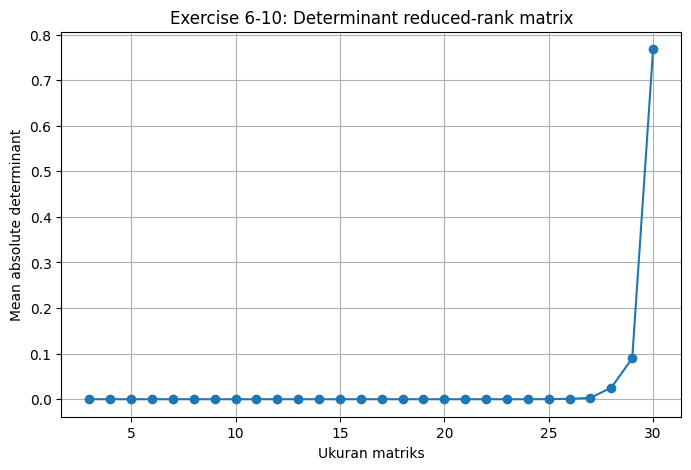

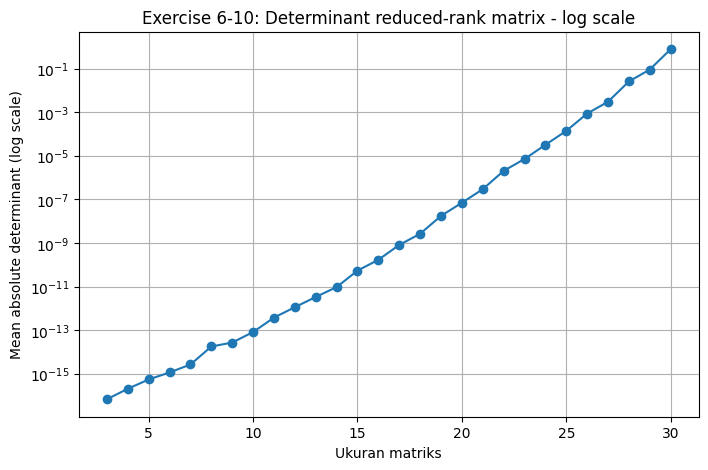

In [19]:
sizes = np.arange(3, 31)
n_repeats = 100
mean_abs_dets = np.zeros(len(sizes))

for si, n in enumerate(sizes):
  dets = np.zeros(n_repeats)
  for ri in range(n_repeats):
    A = np.random.randn(n, n)
    A[:, 1] = 2*A[:, 0]  # membuat kolom bergantung linear
    dets[ri] = abs(np.linalg.det(A))
  mean_abs_dets[si] = np.mean(dets)

plt.figure(figsize=(8, 5))
plt.plot(sizes, mean_abs_dets, 'o-')
plt.xlabel('Ukuran matriks')
plt.ylabel('Mean absolute determinant')
plt.title('Exercise 6-10: Determinant reduced-rank matrix')
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.semilogy(sizes, mean_abs_dets, 'o-')
plt.xlabel('Ukuran matriks')
plt.ylabel('Mean absolute determinant (log scale)')
plt.title('Exercise 6-10: Determinant reduced-rank matrix - log scale')
plt.grid(True)
plt.show()

Secara teori determinant matriks reduced-rank adalah nol. Namun hasil komputasi dapat menunjukkan nilai sangat kecil yang bukan tepat nol karena keterbatasan presisi numerik saat menghitung determinant pada komputer.

## Ringkasan Akhir

Bab ini membahas perluasan konsep matriks: Frobenius norm, trace, column space, row space, null space, rank, rank aplikasi, determinant, dan characteristic polynomial. Exercise memperlihatkan bahwa konsep-konsep tersebut dapat diuji langsung dengan NumPy dan SciPy.